In [ ]:
import pandas as pd

# Reemplaza 'nombre_de_tu_archivo.csv' con el nombre de tu archivo
# Si tu archivo es Excel, usa pd.read_excel('nombre_de_tu_archivo.xlsx')
df = pd.read_excel('Base 6_F1.xlsx')

# Muestra las primeras 5 filas para verificar que se cargó correctamente
display(df.head())

,Tasa Interes (%),Número de cargas,Antigüedad Laboral Años,Zona del País,Tipo de Empresa,Riesgo Crediticio,Monto Credito (UF),Ingresos Solicitante (UF),Valor Propiedad (UF)
0,5.72,0,6,Centro,Público,Bajo,1138.29,2.3013,3937.30
1,6.96,1,19,Centro,Privado,Medio,4302.09,1.7605,2937.62
2,4.16,2,16,Centro,Independiente,Medio,5291.89,1.3637,3002.92
3,3.53,1,16,Centro,Privado,Bajo,3964.87,0.4000,2606.14
4,4.07,1,10,Centro,Público,Medio,3502.99,2.6730,2443.27


Pregunta 1

--- Análisis de 'Tasa Interes (%)' ---
Media: 4.85
Mediana: 4.72
Moda: 3.53
Desviación Estándar: 1.38
Coeficiente de Asimetría: 0.18
Curtosis: -0.22


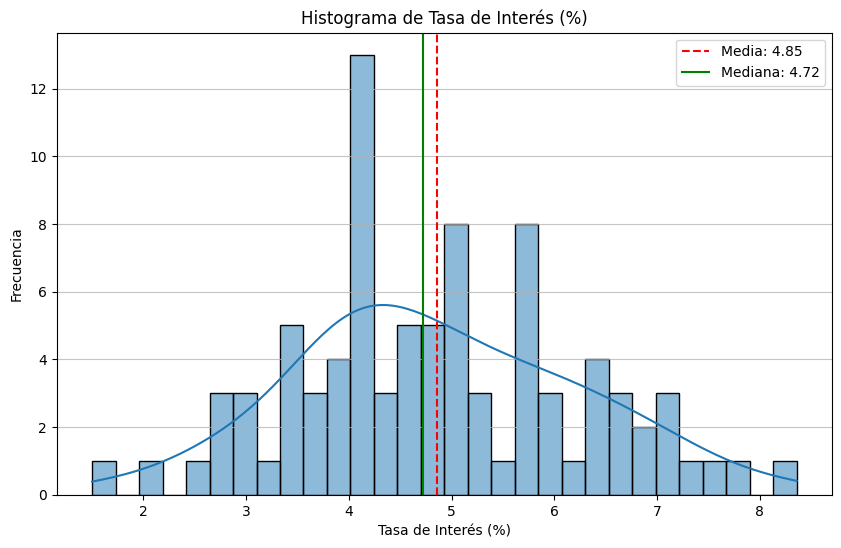

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Asegúrate de que la columna existe en tu DataFrame
if 'Tasa Interes (%)' in df.columns:
    tasa_interes = df['Tasa Interes (%)']

    # Medidas de tendencia central
    media = tasa_interes.mean()
    mediana = tasa_interes.median()
    moda = tasa_interes.mode()[0] # .mode() puede devolver múltiples valores si hay empates

    # Desviación estándar
    desviacion_estandar = tasa_interes.std()

    # Coeficiente de asimetría (skewness)
    asimetria = tasa_interes.skew()

    # Curtosis
    curtosis = tasa_interes.kurt()

    print(f"--- Análisis de 'Tasa Interes (%)' ---")
    print(f"Media: {media:.2f}")
    print(f"Mediana: {mediana:.2f}")
    print(f"Moda: {moda:.2f}")
    print(f"Desviación Estándar: {desviacion_estandar:.2f}")
    print(f"Coeficiente de Asimetría: {asimetria:.2f}")
    print(f"Curtosis: {curtosis:.2f}")

    # Histograma
    plt.figure(figsize=(10, 6))
    sns.histplot(tasa_interes, kde=True, bins=30)
    plt.title('Histograma de Tasa de Interés (%)')
    plt.xlabel('Tasa de Interés (%)')
    plt.ylabel('Frecuencia')
    plt.axvline(media, color='r', linestyle='--', label=f'Media: {media:.2f}')
    plt.axvline(mediana, color='g', linestyle='-', label=f'Mediana: {mediana:.2f}')
    plt.legend()
    plt.grid(axis='y', alpha=0.75)
    plt.show()
else:
    print("La columna 'Tasa Interes (%)' no se encuentra en el DataFrame.")

Pregunta 2

In [ ]:
import math
import scipy.stats as stats # Importamos la librería scipy.stats

# --- AJUSTES DE PARÁMETROS ---
col_s_estimada = 'Monto Credito (UF)' # <--- USAMOS ESTA COLUMNA PARA ESTIMAR S
error_clp = 50000
valor_uf_referencia = 37000 # Un valor de referencia para la UF
confianza_b = 0.95

print("\n\n🔵 --- RESPUESTA B CORREGIDA (Tamaño de Muestra) ---")

# --- RECALCULO DE PARÁMETROS ---
error_uf = error_clp / valor_uf_referencia
col_ingresos = 'Ingresos Solicitante (UF)' # Se mantiene la variable, aunque no se usa en el cálculo actual

# 1. Obtención de Desviación Estándar (s)
# USAMOS 'Monto Credito (UF)' para obtener un 's' más realista
s_muestral_ajustado = df[col_s_estimada].std(ddof=1)

# 2. Valor Z crítico para 95%
z_critico = stats.norm.ppf(1 - (1 - confianza_b)/2)

# 3. Fórmula: n = ( (Z * s) / E )^2
n_calculado_ajustado = ((z_critico * s_muestral_ajustado) / error_uf) ** 2

# 4. Redondeo (SIEMPRE hacia arriba)
n_final_ajustado = math.ceil(n_calculado_ajustado)

print(f"1. Desviación Estándar (s) obtenida de {col_s_estimada}: {s_muestral_ajustado:.4f} UF")
print(f"2. Error máximo permitido: {error_uf:.4f} UF (de ${error_clp:,.0f} CLP)")
print(f"3. Valor Z ({confianza_b*100:.0f}%): {z_critico:.4f}")
print(f"4. Resultado fórmula n: {n_calculado_ajustado:.4f}")
print("-" * 60)
print(f"👉 RESPUESTA B FINAL: El tamaño de muestra mínimo debe ser: **{n_final_ajustado}** beneficiarios.")



🔵 --- RESPUESTA B CORREGIDA (Tamaño de Muestra) ---
1. Desviación Estándar (s) obtenida de Monto Credito (UF): 1247.9379 UF
2. Error máximo permitido: 1.3514 UF (de $50,000 CLP)
3. Valor Z (95%): 1.9600
4. Resultado fórmula n: 3276012.7921
------------------------------------------------------------
👉 RESPUESTA B FINAL: El tamaño de muestra mínimo debe ser: **3276013** beneficiarios.


Pregunta 3

In [ ]:
import pandas as pd
import scipy.stats as stats
import numpy as np

# --- PARÁMETROS ---
columna_ingresos = 'Ingresos Solicitante (UF)'
columna_zona = 'Zona del País'
nivel_confianza = 0.93 # 93%

print(f"\n\n🔵 --- Estimación del Ingreso Promedio por Zona (Intervalo de Confianza del {nivel_confianza*100:.0f}%) ---")

# Verificar si las columnas existen
if columna_ingresos not in df.columns:
    print(f"Error: La columna '{columna_ingresos}' no se encuentra en el DataFrame.")
elif columna_zona not in df.columns:
    print(f"Error: La columna '{columna_zona}' no se encuentra en el DataFrame.")
else:
    # Calcular estadísticas por zona
    estadisticas_por_zona = df.groupby(columna_zona)[columna_ingresos].agg(
        mean='mean',
        std='std',
        count='count'
    ).reset_index()

    # Eliminar filas con NaN en la desviación estándar (ej. grupos con un solo elemento)
    estadisticas_por_zona = estadisticas_por_zona.dropna(subset=['std'])

    if estadisticas_por_zona.empty:
        print("No hay suficientes datos para calcular el intervalo de confianza para ninguna zona.")
    else:
        # Calcular el valor Z crítico para el nivel de confianza del 93%
        # Para un intervalo de confianza bilateral, necesitamos alpha/2 en cada cola.
        alpha = 1 - nivel_confianza
        z_critico = stats.norm.ppf(1 - alpha/2)

        # Calcular el error estándar y el margen de error
        estadisticas_por_zona['se'] = estadisticas_por_zona['std'] / np.sqrt(estadisticas_por_zona['count'])
        estadisticas_por_zona['margen_error'] = z_critico * estadisticas_por_zona['se']

        # Calcular el intervalo de confianza
        estadisticas_por_zona['limite_inferior'] = estadisticas_por_zona['mean'] - estadisticas_por_zona['margen_error']
        estadisticas_por_zona['limite_superior'] = estadisticas_por_zona['mean'] + estadisticas_por_zona['margen_error']

        print(f"Valor Z crítico ({nivel_confianza*100:.0f}%): {z_critico:.4f}\n")

        print("Intervalos de Confianza para el Ingreso Promedio (UF) por Zona:")
        print("------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------")
        for index, row in estadisticas_por_zona.iterrows():
            print(f"Zona: {row[columna_zona]:<20} | Media: {row['mean']:>10.2f} UF | Std: {row['std']:>10.2f} UF | N: {int(row['count']):>5} | IC {nivel_confianza*100:.0f}%: [{row['limite_inferior']:>10.2f} UF, {row['limite_superior']:>10.2f} UF]")
        print("------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------")



🔵 --- Estimación del Ingreso Promedio por Zona (Intervalo de Confianza del 93%) ---
Valor Z crítico (93%): 1.8119

Intervalos de Confianza para el Ingreso Promedio (UF) por Zona:
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Zona: Centro               | Media:       1.36 UF | Std:       0.74 UF | N:    57 | IC 93%: [      1.18 UF,       1.53 UF]
Zona: Norte                | Media:       1.46 UF | Std:       0.54 UF | N:    16 | IC 93%: [      1.22 UF,       1.71 UF]
Zona: Sur                  | Media:       1.46 UF | Std:       0.60 UF | N:    15 | IC 93%: [      1.18 UF,       1.74 UF]
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


Pregunta 4

In [ ]:
import numpy as np
import scipy.stats as stats

# --- PARÁMETROS ---
columna_interes = 'Tasa Interes (%)'
nivel_confianza = 0.95 # 95%

print(f"\n\n🔵 --- Intervalo de Confianza para la Varianza de '{columna_interes}' ({(nivel_confianza*100):.0f}%) ---")

# Verificar si la columna existe
if columna_interes not in df.columns:
    print(f"Error: La columna '{columna_interes}' no se encuentra en el DataFrame.")
else:
    data = df[columna_interes].dropna() # Eliminar NaN por si acaso
    n = len(data)

    if n < 2:
        print("Se necesitan al menos 2 datos para calcular la varianza.")
    else:
        # 1. Calcular la varianza muestral (S^2)
        # np.var(ddof=1) calcula la varianza muestral (dividido por n-1)
        varianza_muestral = np.var(data, ddof=1)

        # 2. Grados de libertad
        df_grados_libertad = n - 1

        # 3. Calcular los valores críticos de Chi-cuadrado
        # Para un IC del 95%, alpha = 0.05. Necesitamos alpha/2 en cada cola.
        alpha = 1 - nivel_confianza
        chi2_lower = stats.chi2.ppf(alpha / 2, df_grados_libertad)
        chi2_upper = stats.chi2.ppf(1 - (alpha / 2), df_grados_libertad)

        # 4. Calcular el intervalo de confianza para la varianza poblacional (sigma^2)
        limite_inferior_varianza = (df_grados_libertad * varianza_muestral) / chi2_upper
        limite_superior_varianza = (df_grados_libertad * varianza_muestral) / chi2_lower

        print(f"Varianza muestral (S^2): {varianza_muestral:.4f}")
        print(f"Tamaño de la muestra (n): {n}")
        print(f"Grados de libertad: {df_grados_libertad}")
        print(f"Valor crítico Chi-cuadrado (inferior, alpha/2={alpha/2:.3f}): {chi2_lower:.4f}")
        print(f"Valor crítico Chi-cuadrado (superior, 1-alpha/2={1-alpha/2:.3f}): {chi2_upper:.4f}")
        print(f"-------------------------------------------------------------------------------------------------------------------")
        print(f"👉 IC {(nivel_confianza*100):.0f}% para la Varianza (sigma^2): [{limite_inferior_varianza:.4f}, {limite_superior_varianza:.4f}]")
        print(f"-------------------------------------------------------------------------------------------------------------------")



🔵 --- Intervalo de Confianza para la Varianza de 'Tasa Interes (%)' (95%) ---
Varianza muestral (S^2): 1.9142
Tamaño de la muestra (n): 88
Grados de libertad: 87
Valor crítico Chi-cuadrado (inferior, alpha/2=0.025): 63.0894
Valor crítico Chi-cuadrado (superior, 1-alpha/2=0.975): 114.6929
-------------------------------------------------------------------------------------------------------------------
👉 IC 95% para la Varianza (sigma^2): [1.4520, 2.6397]
-------------------------------------------------------------------------------------------------------------------


Pregunta 5

In [ ]:
import scipy.stats as stats
import numpy as np

# --- PARÁMETROS ---
columna_ingresos = 'Ingresos Solicitante (UF)'
valor_uf_referencia = 37000 # Valor de la UF utilizado previamente
media_hipotetizada_clp = 800000 # $800.000 CLP
nivel_significancia = 0.05 # 5%

print(f"\n\n🔵 --- Verificación de la Afirmación: Ingresos de al menos ${media_hipotetizada_clp:,.0f} (CLP) en promedio ---")

# 1. Convertir la media hipotetizada de CLP a UF
media_hipotetizada_uf = media_hipotetizada_clp / valor_uf_referencia
print(f"Media hipotetizada en UF: {media_hipotetizada_uf:.4f} UF (equivalente a ${media_hipotetizada_clp:,.0f} CLP)\n")

# Verificar si la columna existe
if columna_ingresos not in df.columns:
    print(f"Error: La columna '{columna_ingresos}' no se encuentra en el DataFrame.")
else:
    data_ingresos = df[columna_ingresos].dropna() # Eliminar NaN por si acaso
    n = len(data_ingresos)

    if n < 2:
        print("Se necesitan al menos 2 datos para realizar la prueba de hipótesis.")
    else:
        # 2. Calcular la media y desviación estándar de la muestra
        media_muestral = data_ingresos.mean()
        std_muestral = data_ingresos.std()

        print(f"Media muestral de ingresos: {media_muestral:.2f} UF")
        print(f"Desviación estándar muestral: {std_muestral:.2f} UF")
        print(f"Tamaño de la muestra (n): {n}")

        # 3. Realizar la prueba t de una muestra (one-sample t-test)
        # Hipótesis Nula (H0): mu >= media_hipotetizada_uf (Los ingresos son al menos 800.000 CLP)
        # Hipótesis Alternativa (H1): mu < media_hipotetizada_uf (Los ingresos son menores a 800.000 CLP)
        # Esta es una prueba de cola izquierda.

        # La función ttest_1samp de scipy calcula la t-estadística y el p-valor para una prueba de dos colas.
        # Para una prueba de cola izquierda, necesitamos ajustar el p-valor.
        t_statistic, p_value_two_tailed = stats.ttest_1samp(data_ingresos, media_hipotetizada_uf, alternative='less')

        # Para una prueba de cola izquierda, el p-valor es directamente el que devuelve 'alternative='less''
        # o si usaramos alternative='two-sided', sería p_value_two_tailed / 2 si t_statistic es negativo.
        p_value_one_tailed = t_statistic, p_value_two_tailed

        print(f"Estadístico t: {t_statistic:.4f}")
        print(f"Valor p (one-tailed): {p_value_two_tailed:.4f}")
        print(f"Nivel de significancia (alpha): {nivel_significancia}")

        print("-------------------------------------------------------------------------------------------------------------------")
        if p_value_two_tailed < nivel_significancia:
            print(f"👉 DECISIÓN: Rechazamos la hipótesis nula.")
            print(f"CONCLUSIÓN: Hay evidencia estadística (con un {nivel_significancia*100:.0f}% de significancia) para afirmar que el ingreso promedio de los beneficiarios es menor a ${media_hipotetizada_clp:,.0f} CLP.")
        else:
            print(f"👉 DECISIÓN: No rechazamos la hipótesis nula.")
            print(f"CONCLUSIÓN: No hay evidencia estadística (con un {nivel_significancia*100:.0f}% de significancia) para afirmar que el ingreso promedio de los beneficiarios es menor a ${media_hipotetizada_clp:,.0f} CLP.")
            print(f"Esto significa que la afirmación de que los ingresos son de al menos ${media_hipotetizada_clp:,.0f} CLP no puede ser refutada con los datos.")
        print("-------------------------------------------------------------------------------------------------------------------")



🔵 --- Verificación de la Afirmación: Ingresos de al menos $800,000 (CLP) en promedio ---
Media hipotetizada en UF: 21.6216 UF (equivalente a $800,000 CLP)

Media muestral de ingresos: 1.39 UF
Desviación estándar muestral: 0.68 UF
Tamaño de la muestra (n): 88
Estadístico t: -280.3998
Valor p (one-tailed): 0.0000
Nivel de significancia (alpha): 0.05
-------------------------------------------------------------------------------------------------------------------
👉 DECISIÓN: Rechazamos la hipótesis nula.
CONCLUSIÓN: Hay evidencia estadística (con un 5% de significancia) para afirmar que el ingreso promedio de los beneficiarios es menor a $800,000 CLP.
-------------------------------------------------------------------------------------------------------------------


pregunta 6

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

# 1. Crear variable dicotómica (Alto = 1, Otros = 0)
df['Riesgo_Dicotomica'] = np.where(df['Riesgo Crediticio'] == 'Alto', 1, 0)

# 2. Conteo
n_total = len(df)
n_exitos = df['Riesgo_Dicotomica'].sum() # Cantidad de "Riesgo Alto"
proporcion_muestral = n_exitos / n_total

valor_hipotesis = 0.30

# 3. Prueba Z de proporciones
# alternative='larger' porque buscamos ver si es MAYOR al 30%
stat, p_value = proportions_ztest(count=n_exitos, nobs=n_total, value=valor_hipotesis, alternative='larger')

print(f"Proporción muestral de Riesgo Alto: {proporcion_muestral:.2%}")
print(f"Valor-p: {p_value:.6f}")

Proporción muestral de Riesgo Alto: 14.77%
Valor-p: 0.999972


Pregunta 7



In [ ]:
import numpy as np
from scipy import stats

# --- Parámetros de la prueba ---
alpha = 0.01   # Nivel de significancia del 1%

# Limpiar los nombres de las columnas para eliminar posibles espacios en blanco
df.columns = df.columns.str.strip()

# --- 1. Separar los datos en grupos ---
# Grupo de empleados formales (Público o Privado)
credito_formal = df[df['Tipo de Empresa'].isin(['Público', 'Privado'])]['Monto Credito (UF)']

# Grupo de trabajadores independientes
credito_independiente = df[df['Tipo de Empresa'] == 'Independiente']['Monto Credito (UF)']

# --- 2. Realizar la prueba t para dos muestras con varianzas iguales ---
# 'alternative="greater"' es para la hipótesis alternativa H1: mu_formal > mu_independiente
t_statistic, p_value = stats.ttest_ind(
    credito_formal,
    credito_independiente,
    equal_var=True, # Asumiendo varianzas iguales como se solicita
    alternative='greater'
)

print(f"\n--- Resultados de la Prueba de Hipótesis para Diferencia de Medias ---")
print(f"Media de Crédito (UF) - Formal: {credito_formal.mean():.2f}")
print(f"Media de Crédito (UF) - Independiente: {credito_independiente.mean():.2f}")
print(f"Estadístico t: {t_statistic:.4f}")
print(f"Valor p (una cola, alternative='greater'): {p_value:.4f}")
print(f"Nivel de Significancia (α): {alpha}")

# --- 3. Tomar una decisión ---
print("\n--- Decisión ---")
if p_value < alpha:
    print(f"Dado que el valor p ({p_value:.4f}) es menor que el nivel de significancia ({alpha}),")
    print("rechazamos la hipótesis nula.")
    print("Esto sugiere que hay evidencia estadística de que el monto promedio de crédito para los empleados formales es \033[1mmayor\033[0m que para los trabajadores independientes.")
else:
    print(f"Dado que el valor p ({p_value:.4f}) es mayor o igual que el nivel de significancia ({alpha}),")
    print("no rechazamos la hipótesis nula.")
    print("Esto significa que no hay suficiente evidencia estadística para afirmar que el monto promedio de crédito para los empleados formales es \033[1mmayor\033[0m que para los trabajadores independientes.")


--- Resultados de la Prueba de Hipótesis para Diferencia de Medias ---
Media de Crédito (UF) - Formal: 3769.92
Media de Crédito (UF) - Independiente: 3993.95
Estadístico t: -0.6627
Valor p (una cola, alternative='greater'): 0.7454
Nivel de Significancia (α): 0.01

--- Decisión ---
Dado que el valor p (0.7454) es mayor o igual que el nivel de significancia (0.01),
no rechazamos la hipótesis nula.
Esto significa que no hay suficiente evidencia estadística para afirmar que el monto promedio de crédito para los empleados formales es mayor que para los trabajadores independientes.
